# Summary of Key Concepts: Probability Distributions & Central Limit Theorem

## Main Ideas

### 1. Binomial Distribution
**What it describes**: Number of successes in $N$ independent trials, each with probability $\mu$

**Applications**: Coin flips, yes/no surveys, binary classification results

**Key insight**: Discrete distribution (countable outcomes)

### 2. Gaussian (Normal) Distribution
**What it describes**: Continuous bell-shaped distribution, ubiquitous in nature

**Why it's everywhere**: Central Limit Theorem!

**Key insight**: Continuous distribution (smooth curve)

### 3. Central Limit Theorem (CLT)
**The Big Idea**: Average of many random variables → Gaussian distribution

**No matter what the original distribution looks like!**

**This explains why**: 
- Measurement errors are normally distributed
- Heights, test scores, etc. follow normal curves
- Real-world data often looks Gaussian

---

## Key Equations

### Binomial Distribution
$$
\text{Bin}(m | N, \mu) = \binom{N}{m} \mu^m (1-\mu)^{N-m}
$$

Where:
- $m$: number of successes (0 to N)
- $N$: number of trials
- $\mu$: probability of success on each trial

**Mean**: $E[m] = N\mu$

**Variance**: $\text{Var}[m] = N\mu(1-\mu)$

**Example**: Flip 10 coins ($N=10$), probability of heads $\mu=0.5$. How many heads ($m$)?

---

### Gaussian Distribution
$$
\mathcal{N}(x | \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right]
$$

Where:
- $\mu$: mean (center of bell curve)
- $\sigma^2$: variance (width of bell curve)
- $\sigma$: standard deviation

**Properties**:
- Symmetric around $\mu$
- ~68% of data within $\mu \pm \sigma$
- ~95% of data within $\mu \pm 2\sigma$
- ~99.7% of data within $\mu \pm 3\sigma$

---

### Central Limit Theorem (Formal Statement)

Let $x = m/N$ where $m \sim \text{Bin}(N, \mu)$. As $N \to \infty$:

$$
p(x) \to \mathcal{N}\left(x \bigg| \mu, \frac{\mu(1-\mu)}{N}\right)
$$

**Key observations**:
- Mean stays the same: $x^* = \mu$
- Variance decreases: $\sigma^2 = \frac{\mu(1-\mu)}{N}$
- As $N \to \infty$, variance $\to 0$ (sharper peak)

---

### Stirling's Approximation
$$
\ln N! \approx N(\ln N - 1) \quad \text{for } N \gg 1
$$

**Why useful**: Simplifies factorials in binomial distribution when N is large

**Leads to**: Showing binomial → Gaussian using $p(x) \propto \exp[Nf(x)]$

---

## Important Concepts

### 1. Method of Steepest Descent (Laplace Approximation)

**Idea**: For large N, $p(x) \propto e^{Nf(x)}$ is dominated by maximum of $f(x)$

**Steps**:
1. Find $x^*$ that maximizes $f(x)$: $\frac{df}{dx}\bigg|_{x=x^*} = 0$
2. Taylor expand around $x^*$:
$$f(x) \approx f(x^*) + \frac{1}{2}f''(x^*)(x-x^*)^2$$
3. Result: 
$$p(x) \propto \exp\left[-\frac{(x-x^*)^2}{2\sigma^2}\right]$$
where $\sigma^2 = -\frac{1}{Nf''(x^*)}$

**Conclusion**: Binomial becomes Gaussian for large N!

---

### 2. Sample Mean Distribution

If $\{x_1, x_2, \ldots, x_N\}$ are independent samples from **any** distribution:

**Sample mean**: $\bar{x} = \frac{1}{N}\sum_{i=1}^N x_i$

**CLT says**: As $N \to \infty$, $\bar{x}$ becomes normally distributed with:
- Mean: $\mu_{\bar{x}} = \mu$ (original distribution's mean)
- Variance: $\sigma_{\bar{x}}^2 = \frac{\sigma^2}{N}$ (divided by N!)

**Standard error**: $\text{SE} = \frac{\sigma}{\sqrt{N}}$ (uncertainty in mean)

**Key insight**: Averaging reduces variance by factor of N!

---

### 3. Variance Formula for Binomial

For $x = m/N$ where $m \sim \text{Bin}(N, \mu)$:

$$\text{Var}[x] = \frac{\mu(1-\mu)}{N}$$

**Verification**: 
- $\text{Var}[m] = N\mu(1-\mu)$ (binomial variance)
- $\text{Var}[m/N] = \frac{1}{N^2}\text{Var}[m] = \frac{\mu(1-\mu)}{N}$ ✓

**Observation**: As $N$ increases, variance decreases as $1/N$

---

## Coding Functions

### 1. Generate Binomial Samples
```python
# Generate M samples from Bin(N, mu)
M = 10000  # number of samples
N = 100    # number of trials
mu = 0.8   # probability of success

m_samples = np.random.binomial(N, mu, M)
x_samples = m_samples / N  # Normalize to [0,1]

# Plot histogram
plt.hist(x_samples, bins=30)
plt.xlabel('x = m/N')
plt.ylabel('Frequency')
plt.title(f'Binomial Distribution (N={N}, μ={mu})')
```

### 2. Compute Variance
```python
def compute_variance(M, N, mu):
    """
    Compute variance of x = m/N where m ~ Bin(N, mu)
    """
    m_samples = np.random.binomial(N, mu, M)
    x_samples = m_samples / N
    
    # Empirical variance
    var_empirical = np.var(x_samples)
    
    # Theoretical variance
    var_theoretical = mu * (1 - mu) / N
    
    return var_empirical, var_theoretical
```

### 3. Verify CLT with Sample Means
```python
def compute_sample_means(data, N, M=1000):
    """
    Randomly sample N points, compute mean, repeat M times.
    Tests CLT on any data (not just binomial).
    """
    sample_means = []
    for _ in range(M):
        sample = np.random.choice(data, size=N, replace=True)
        sample_means.append(np.mean(sample))
    return np.array(sample_means)

# Example: Word lengths from a novel
word_lengths = [4, 3, 5, 8, ...]  # any data!
sample_means = compute_sample_means(word_lengths, N=50, M=1000)

# Should look Gaussian!
plt.hist(sample_means, bins=30)
```

---

## Visual Understanding

### Small N (e.g., N=20)
```
Binomial Distribution:
  ▁▃▅█▇▅▃▁     ← Discrete, possibly skewed
  0 1 2 3 4 ... 20
```

### Large N (e.g., N=10,000)
```
Binomial ≈ Gaussian:
     ╱‾‾‾╲       ← Smooth bell curve
    ╱     ╲
   ╱       ╲
  ╱_________╲
```

### Effect of Averaging (CLT)
```
Original Data:
    ▂▁▆██▃▂        ← Any shape (e.g., word lengths)

Sample Means (N=50):
      ╱‾╲          ← Becomes Gaussian!
     ╱   ╲
    ╱_____╲
```

---

## Expected Behavior

### Exercise 1: Binomial Histograms
- **N = 20**: Discrete bars, may look asymmetric (skewed)
- **N = 10,000**: Smooth curve, symmetric, bell-shaped (Gaussian!)

**Why**: Large N → CLT kicks in → binomial looks like Gaussian

---

### Exercise 2: Variance vs N
On log-log plot:
- **Empirical variance** (from simulations)
- **Theoretical variance** ($\mu(1-\mu)/N$)
- Should **overlap perfectly**
- Both follow $\propto 1/N$ (straight line on log-log plot with slope -1)

---

### Exercise 3: Real-World CLT (Word Lengths)

**Part a**: Original word lengths
- Distribution is **NOT Gaussian** (skewed, discrete)
- Many short words, few very long words

**Part c**: Sample means (N=50)
- Distribution **IS Gaussian** (symmetric, bell-shaped)
- **CLT magic**: Even though original data isn't normal, averages are!

**Part d**: Gaussianness metric (Shapiro-Wilk W statistic)
- **Small N**: W far from 1 (not Gaussian)
- **Large N**: W close to 1 (very Gaussian)
- **Trend**: Monotonically increasing with N

---

## Critical Concepts

### ✅ Understand These:

1. **Binomial vs Gaussian**:
   - Binomial: discrete (coin flips, counts)
   - Gaussian: continuous (measurements, averages)

2. **Why CLT matters**:
   - Explains why normal distributions appear everywhere
   - Justifies using Gaussian models for averaged data
   - Foundation for confidence intervals and hypothesis testing

3. **Variance decreases with N**:
   - More data → more precise estimates
   - Standard error ∝ $1/\sqrt{N}$
   - Want 2× precision? Need 4× data!

4. **CLT applies broadly**:
   - Original data can be **any** distribution
   - Sample means still → Gaussian
   - This is incredibly powerful!

---

## Common Mistakes

### ❌ DON'T:

1. **Confuse m and x**: 
   - $m$: number of successes (integer, 0 to N)
   - $x = m/N$: fraction of successes (real number, 0 to 1)

2. **Forget to normalize**:
   - Binomial variance: $N\mu(1-\mu)$
   - Normalized variance: $\mu(1-\mu)/N$ (divide by $N^2$!)

3. **Expect CLT for small N**:
   - Need $N \gg 1$ for CLT to work well
   - Rule of thumb: N > 30 is usually enough

4. **Think CLT only applies to binomial**:
   - Works for **any** distribution (that's the point!)
   - Coin flips, word lengths, stock prices, etc.

---

## Mathematical Techniques

### Stirling + Steepest Descent Workflow

**Goal**: Show $\text{Bin}(m|N,\mu) \to \mathcal{N}(x|\mu, \sigma^2)$ for large N

**Steps**:
1. Write binomial distribution with factorials
2. Apply Stirling: $\ln N! \approx N(\ln N - 1)$
3. Get $p(x) \propto e^{Nf(x)}$ for some $f(x)$
4. Find maximum: $f'(x^*) = 0$
5. Taylor expand: $f(x) \approx f(x^*) + \frac{1}{2}f''(x^*)(x-x^*)^2$
6. Recognize Gaussian form!

**Result**: 
- $x^* = \mu$ (mean)
- $\sigma^2 = \mu(1-\mu)/N$ (variance)

---

## Typical Workflow

### Verifying CLT Numerically

```python
# 1. Choose distribution (e.g., binomial)
N_trials = 100
mu_prob = 0.6

# 2. Generate many samples of sample means
M = 10000  # Number of experiments
sample_means = []

for _ in range(M):
    # Draw N samples, compute mean
    samples = np.random.binomial(N_trials, mu_prob, size=N_trials)
    sample_means.append(np.mean(samples))

# 3. Plot histogram (should look Gaussian)
plt.hist(sample_means, bins=50, density=True, alpha=0.7, label='Empirical')

# 4. Overlay theoretical Gaussian
x = np.linspace(min(sample_means), max(sample_means), 100)
mu_theory = N_trials * mu_prob
sigma_theory = np.sqrt(N_trials * mu_prob * (1 - mu_prob))
gaussian = (1/(sigma_theory*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu_theory)/sigma_theory)**2)
plt.plot(x, gaussian, 'r-', linewidth=2, label='Theory')

plt.legend()
plt.show()
```

---

## Shapiro-Wilk Test (Bonus)

**Purpose**: Quantify "how Gaussian" a distribution is

**W statistic**: 
- Range: 0 to 1
- W ≈ 1: Very Gaussian
- W ≪ 1: Not Gaussian

**Usage**:
```python
from scipy import stats
stat, pvalue = stats.shapiro(data)
print(f"W = {stat:.4f}, p-value = {pvalue:.4e}")
```

**Interpretation**:
- High W (close to 1): Data looks Gaussian
- Low p-value: Reject normality (data NOT Gaussian)
- High p-value: Cannot reject normality (data consistent with Gaussian)

---

## Key Takeaways

1. **Binomial → Gaussian** as N increases (CLT for sum of Bernoulli trials)

2. **Any distribution → Gaussian** for sample means as N increases (CLT general form)

3. **Variance decreases as $1/N$** when averaging (precision improves with data)

4. **Stirling + steepest descent** proves binomial → Gaussian mathematically

5. **Real data obeys CLT** (word lengths, any messy data → averages are Gaussian)

6. **Normal distribution is universal** because of CLT (not because everything is inherently Gaussian!)

---

## Connection to Machine Learning

**Why this matters for ML**:

1. **Error distributions**: Prediction errors often Gaussian (CLT!)
2. **Gradient descent**: Stochastic gradients (averages) → Gaussian noise
3. **Confidence intervals**: Based on CLT (sample means are normal)
4. **Maximum likelihood**: Gaussian appears everywhere due to CLT
5. **Bayesian inference**: Prior/posterior often Gaussian (conjugate pairs)

**Bottom line**: CLT is fundamental to understanding uncertainty in ML!

# Mathematical exercises

Solutions to the following exercises may be either typed into the submitted Jupyter notebook, or handwritten solutions may be scanned and submitted as a separate PDF file.


**Exercise 1** (3 points): Problem 2.4 from the PRML textbook.

**Exercise 2** (5 points): Problem 2.18 from the PRML textbook.

##  The Central Limit Theorem for the binomial distribution

In class, we focused on the binomial distribution, which describes discrete variables, as well as the Gaussian (aka normal) distribution, which describes continuous variables. One reason, among zillions, for why the Gaussian function is useful and ubiquitous is because of the Central Limit Theorem, which states that, under some mild assumptions, a sum of a large number of random variables (or, equivalently, the mean, which is just the sum divided by the number of variables) tends to be normally distributed, even if the variables themselves do not come from a normal distribution.

Here, we will show that the binomial distribution becomes a normal distribution when the number of samples becomes large. Recall that a variable $m$ drawn from the binomial distribution $\mathrm{Bin}(m | N, \mu)$ describes the number of observations in which a binary variable takes the value 1, given that there are $N$ total observations, and each observation gives 1 with probability $\mu$ (or 0 otherwise). If we let $x = m/N$, then $x$ is a random variable describing the fraction of observations in which 1 is observed.

Because $x$ is an average of $N$ random binary variables, we expect the Central Limit Theorem to apply. In the two exercises that follow, we will show that $p(x)$, where $x=m/N$ and $m \sim \mathrm{Bin}(x | N, \mu)$ becomes a normal distribution as $N \to \infty$.

**Exercise 3a** (2 points): Use Stirling's approximation $\ln N! \approx N(\ln N - 1)$ (valid for $N \gg 1$) to show that, for $N \gg 1$, $p(x) \propto \exp[N f(x)]$, where $f(x)$ is independent of $N$, and derive $f(x)$.

**Exercise 3b** (2 points). For $N \gg 1$, we can apply the method of steepest descent, which means that the exponential in $p(x)$ will be vanishingly small except for values of $x$ very close to the maximum of $f(x)$. Solve for $x^*$ which maximizes $f(x)$ and perform a Taylor expansion to second order, leading to $p(x) \propto \exp[-\frac{1}{2\sigma^2}(x - x^*)^2]$ (we aren't worried about the normalization in front of the exponent). What are $x^*$ and $\sigma$? How are they related to the mean and variance of the binomial distribution that we started with? This relation turns out to be a general one, applying to other distributions as well as the binomial distribution.



# Coding exercises

In the exercises that follow, we will use simulated data to check the predictions of the Central Limit Theorem.

Reminder: Once your notebook is complete, you should restart the kernel, run all of the cells in order, and make sure that no errors occur. Notebooks that run successfully without errors will be awarded one extra credit point.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

**Exercise 1** (3 points): Let $\{m_1, m_2, \ldots, m_M\}$ be random variables drawn from the binomial distribution $\mathrm{Bin}(m | N, \mu)$, and let $x_i = m_i/N$. Plot two histograms of the distributions of $x_i$: one with $N=20$ and another with $N=10,000$. In both plots, use $M = 10,000$ and $\mu = 0.8$. The function `np.random.binomial()` may be useful. Give each plot appropriate axes labels and title. Describe how the two distributions appear to differ.

In [2]:
m_samples = np.random.binomial(N, mu, M)  # M samples from Bin(N, mu)
m_samples

NameError: name 'N' is not defined

In [58]:
x_samples.shape

(10000,)

In [65]:
?np.random.binomial

Docstring:
binomial(n, p, size=None)

Draw samples from a binomial distribution.

Samples are drawn from a binomial distribution with specified
parameters, n trials and p probability of success where
n an integer >= 0 and p is in the interval [0,1]. (n may be
input as a float, but it is truncated to an integer in use)

.. note::
    New code should use the `~numpy.random.Generator.binomial`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

Parameters
----------
n : int or array_like of ints
    Parameter of the distribution, >= 0. Floats are also accepted,
    but they will be truncated to integers.
p : float or array_like of floats
    Parameter of the distribution, >= 0 and <=1.
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
    ``m * n * k`` samples are drawn.  If size is ``None`` (default),
    a single value is returned if ``n`` and ``p`` are both scalars.
    Otherw

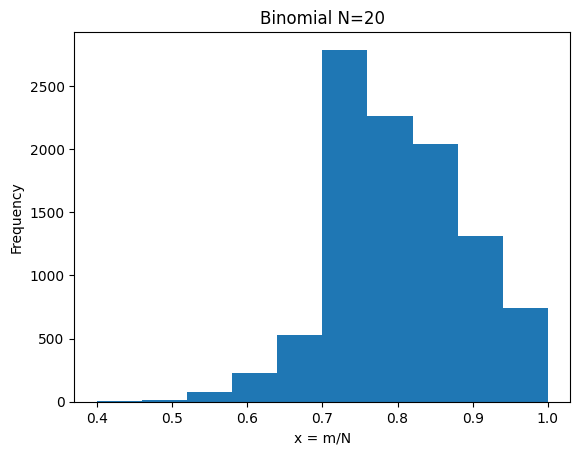

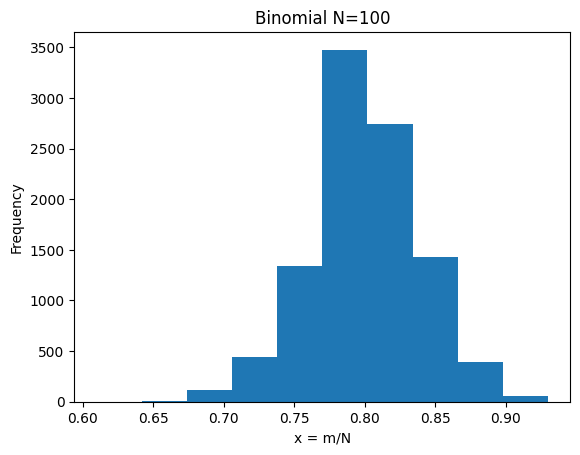

In [59]:
## Solution ##

M = 10000
mu = 0.8

# For N=20
N = 20
m_samples = np.random.binomial(N, mu, M)  # M samples from Bin(N, mu)
x_samples = m_samples / N

plt.figure()
plt.hist(x_samples)  
plt.xlabel('x = m/N')
plt.ylabel('Frequency')
plt.title(f'Binomial N={N}')
plt.show()

# For N=100
N = 100
m_samples = np.random.binomial(N, mu, M)  
x_samples = m_samples / N

plt.figure()
plt.hist(x_samples)  
plt.xlabel('x = m/N')
plt.ylabel('Frequency')
plt.title(f'Binomial N={N}')
plt.show()


The N = 20 distribution is a skewed version (the way its skewed depends on the random generation of the data) of the normal whereas N = 100 appears to resemble the normal generally well just in discrete chunks.

**Exercise 2** (3 points): Create a function `f(M, N, mu)` that takes $M$, $N$, and $\mu$ (as defined in the previous exercise) as inputs and returns the variance of the distribution of $M$ random variables $x_i = m_i/N$, where $m_i \sim \text{Bin}(N,\mu)$ (i.e. the distribution plotted in the previous exercise). Plot this variance on a log-log plot for various values of `N`, with `M=10000` and `mu=0.8`. In the same figure, also plot the result you obtained for the variance in the mathematical exercises on the Central Limit Theorem above.

var_hat: 0.15837271000000003
var: 0.15837271
var_hat: 0.07972959500000001
var: 0.07845918999999998
var_hat: 0.032035982000000005
var: 0.03188391
var_hat: 0.015927253590000003
var: 0.015791535900000004
var_hat: 0.010662665999999998
var: 0.010793323333333335
var_hat: 0.008021574080000003
var: 0.007996481599999999
var_hat: 0.003209108447999999
var: 0.0032093423999999993
var_hat: 0.0016012175879100002
var: 0.0016350487909999995
var_hat: 0.00032030850769632004
var: 0.0003216914481599994
var_hat: 0.000160021598704
var: 0.00015953870399999958
var_hat: 3.199081162771327e-05
var: 3.333563456640004e-05
var_hat: 1.600019259896959e-05
var: 1.6014614695899995e-05


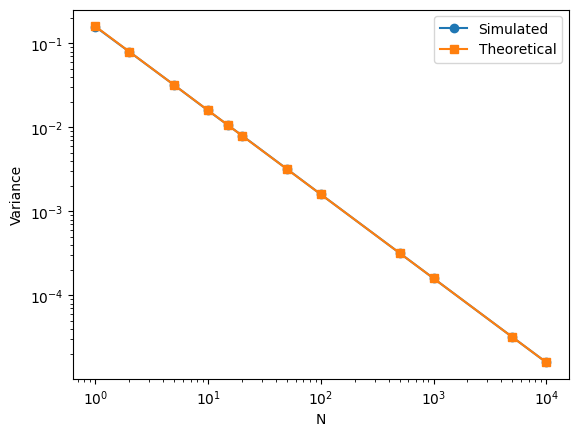

In [ ]:
## Solution ##
def f(M, N, mu):
    # Generate M samples from Bin(N, mu)
    m_samples = np.random.binomial(N, mu, M)
    x_samples = m_samples / N
    mu_hat = np.mean(x_samples)
    # print(f"mu_hat: {mu_hat}")
    var_hat = mu_hat*(1-mu_hat)/N # MLE of variance
    # print(f"var_hat: {var_hat}")
    var = np.var(x_samples) # vs np.var
    # print(f"var: {var}")
    return var_hat


# N_values = np.linspace(1, 50, 50, dtype=int)
N_values = [1,2, 5, 10, 15, 20, 50, 100, 500, 1000, 5000, 10000]
variances = [f(10000, N, 0.8) for N in N_values]

plt.loglog(N_values, variances, 'o-', label='Simulated')

var_theoretical = [mu * (1 - mu) / N for N in N_values]
plt.loglog(N_values, var_theoretical, 's-', label='Theoretical')
plt.xlabel('N')
plt.ylabel('Variance')
plt.legend()

**Exercise 3** (6 points):

In the previous exercises, we demonstrated the Central Limit Theorem (CLT) using a mathematically pure Binomial distribution. In the real world, data is often "messy" and follows unknown distributions. In this exercise, you will use AI to help you gather unstructured data and verify that the CLT still holds.

**Exercise 3a** (2 points): Use an AI coding assistant (like ChatGPT or GitHub Copilot) to write a Python script that performs the following data preparation steps:
1.  Downloads the raw text of your favorite novel from Project Gutenberg (URL: `https://www.gutenberg.org/files/1342/1342-0.txt`).
2.  Cleans the text: removes punctuation and special characters, and splits the text into a list of individual words.
3.  Creates a list of integers representing the *length of every word* in the novel.
4.  Plot a histogram of the individual word lengths. Does this distribution look Gaussian? 

**Exercise 3c** (2 points): Write a function (or ask the AI to write one) that randomly selects $N$ words from your list, calculates their mean length, and repeats this process $M=1000$ times to create a list of "sample means." 
   * Plot a histogram of these sample means for $N=50$. 
   * Describe the shape of this new distribution compared to the plot in **3b**.

**Exercise 3d** (2 points): Ask your AI assistant to recommend a single scalar metric that quantifies "how Gaussian" a distribution is. 
   * Calculate this metric for the distribution of sample means for a range of sample sizes: $N \in [1, 2, 5, 10, 30, 50, 100]$. 
   * Plot this metric vs. $N$. How does the "Gaussian-ness" of the distribution change as you average over more data?

Total words: 127315
First 10 word lengths: [5, 2, 3, 7, 9, 5, 4, 12, 6, 5]


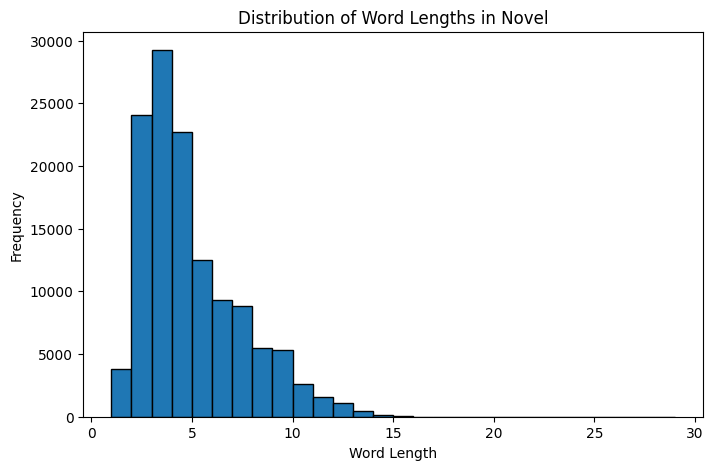

In [61]:
## Solution ##
import urllib.request
import string
import ssl

# 1. Download the text (with SSL context to avoid certificate issues)
url = "https://www.gutenberg.org/files/1342/1342-0.txt"
try:
    # Create SSL context to handle certificate verification
    context = ssl._create_unverified_context()
    with urllib.request.urlopen(url, context=context) as response:
        text = response.read().decode('utf-8')
except Exception as e:
    print(f"Error downloading: {e}")
    # Alternative: use requests library
    import requests
    response = requests.get(url)
    text = response.text

# 2. Clean the text: remove punctuation and split into words
# Remove punctuation
translator = str.maketrans('', '', string.punctuation)
cleaned_text = text.translate(translator)
# Split into words and convert to lowercase
words = cleaned_text.lower().split()

# 3. Get word lengths
word_lengths = [len(word) for word in words]

print(f"Total words: {len(word_lengths)}")
print(f"First 10 word lengths: {word_lengths[:10]}")

# 4. Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(word_lengths, bins=range(1, max(word_lengths)+1), edgecolor='black')
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.title('Distribution of Word Lengths in Novel')
plt.show()

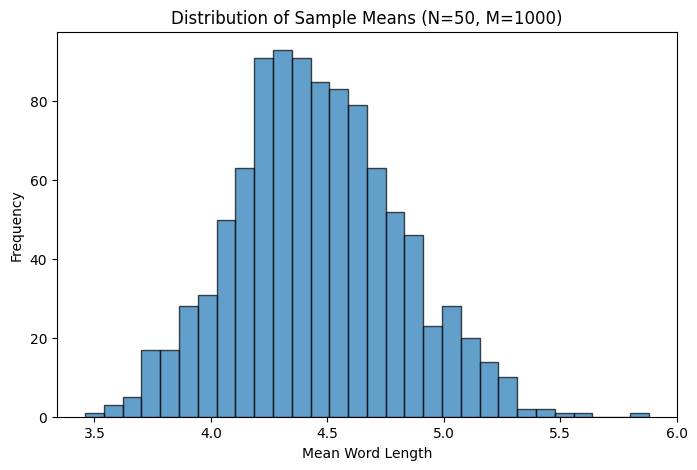

Mean of sample means: 4.459
Std of sample means: 0.350


In [62]:
## Exercise 3c ##

def compute_sample_means(word_lengths, N, M=1000):
    """
    Randomly select N words, calculate mean length, repeat M times.
    Returns list of M sample means.
    """
    sample_means = []
    for _ in range(M):
        # Randomly select N words with replacement
        sample = np.random.choice(word_lengths, size=N, replace=True)
        # Calculate mean of this sample
        sample_means.append(np.mean(sample))
    return sample_means

# Get sample means for N=50
sample_means_50 = compute_sample_means(word_lengths, N=50, M=1000)

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(sample_means_50, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Mean Word Length')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Means (N=50, M=1000)')
plt.show()

print(f"Mean of sample means: {np.mean(sample_means_50):.3f}")
print(f"Std of sample means: {np.std(sample_means_50):.3f}")

N=  1: W-statistic = 0.8888, p-value = 3.3220e-26
N=  2: W-statistic = 0.9483, p-value = 3.1525e-18
N=  5: W-statistic = 0.9813, p-value = 4.9236e-10
N= 10: W-statistic = 0.9884, p-value = 4.2775e-07
N= 30: W-statistic = 0.9977, p-value = 1.9107e-01
N= 50: W-statistic = 0.9974, p-value = 1.1851e-01
N=100: W-statistic = 0.9984, p-value = 4.9263e-01


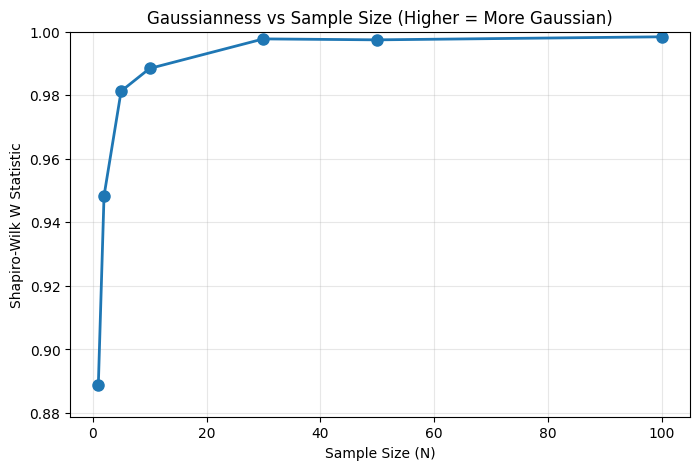

In [63]:
## Exercise 3d ##
from scipy import stats

# The Shapiro-Wilk test is a good metric for "Gaussianness"
# The W statistic ranges from 0 to 1, where closer to 1 means more Gaussian

# Calculate Shapiro-Wilk statistic for different N values
N_values = [1, 2, 5, 10, 30, 50, 100]
gaussianness = []

for N in N_values:
    sample_means = compute_sample_means(word_lengths, N=N, M=1000)
    # Shapiro-Wilk test: statistic closer to 1 = more Gaussian
    stat, pvalue = stats.shapiro(sample_means)
    gaussianness.append(stat)
    print(f"N={N:3d}: W-statistic = {stat:.4f}, p-value = {pvalue:.4e}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(N_values, gaussianness, 'o-', linewidth=2, markersize=8)
plt.xlabel('Sample Size (N)')
plt.ylabel('Shapiro-Wilk W Statistic')
plt.title('Gaussianness vs Sample Size (Higher = More Gaussian)')
plt.grid(True, alpha=0.3)
plt.ylim([min(gaussianness) - 0.01, 1.0])
plt.show()


As N increases, the W-statistic approaches 1,
indicating the distribution of sample means becomes more Gaussian.
This demonstrates the Central Limit Theorem